<a href="https://colab.research.google.com/github/aniketpathak028/computer-vision/blob/main/ViT_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import necessary lib
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn

In [ ]:
transform = transforms.Compose([transforms.ToTensor()])

In [ ]:
# import dataset
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
val_dataset = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 42.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.16MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.72MB/s]


In [ ]:
# define variables
img_size= 28 # MNIST images are 28x28
patch_size= 7
batch_size= 64
num_patches = (img_size // patch_size) ** 2
embedding_dim = 64
attention_heads = 4
transformer_blocks = 4
mlp_hidden_nodes = 128
learning_rate = 0.001
epochs = 5
num_channels = 1
num_classes= 10

In [ ]:
# define dataset batches
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
# grab a batch of image and labels
images, labels= next(iter(train_loader))
print(f"Images batch shape: {images.shape}")
print(f"Labels batch shape: {labels.shape}")

Images batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


In [ ]:
# part 1 : patch embedding
# part 2 : transformer encoder
# part 3 : MLP_head
# part 4 : transformer class

In [ ]:
# understanding the dimensions
patch_embed = nn.Conv2d(num_channels, embedding_dim, kernel_size = patch_size, stride = patch_size)
patched_output= patch_embed(images)
print(patched_output.shape)

# flatten the patches
flattened_output= patched_output.flatten(2)
print(flattened_output.shape)

torch.Size([64, 64, 4, 4])
torch.Size([64, 64, 16])


In [ ]:
# part 1 : patch embedding
class PatchEmbedding(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embed = nn.Conv2d(num_channels, embedding_dim, kernel_size = patch_size, stride = patch_size)

  def forward(self, x):
    # things to do
    # 1. patch embedding
    x= self.patch_embed(x)
    # 2. flattening
    x= x.flatten(2)
    # 3. transpose for matching shape to the expected transformer input shape - [batch, seq_len, embedding dim]
    # current shape - [batch, dim, seq_len] - so we must swap dim 1 and 2
    x= x.transpose(1,2)
    return x

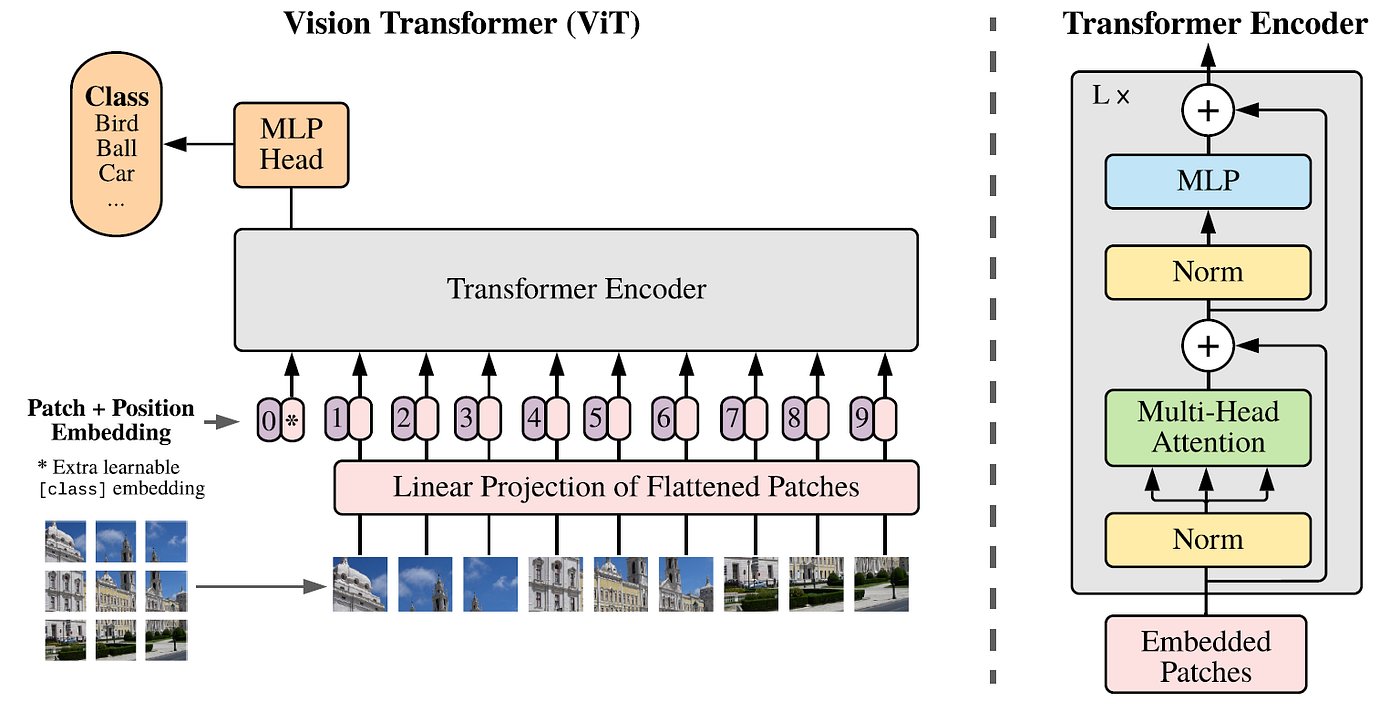

In [ ]:
# part 2 : Transformer encoder
class TransformerEncoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm1 = nn.LayerNorm(embedding_dim)
    self.layer_norm2 = nn.LayerNorm(embedding_dim)
    self.multihead_attention = nn.MultiheadAttention(embedding_dim, attention_heads, batch_first=True)
    self.mlp= nn.Sequential(
        nn.Linear(embedding_dim, mlp_hidden_nodes),
        nn.GELU(),
        nn.Linear(mlp_hidden_nodes, embedding_dim),
    )

  def forward(self, x):
    residual1 = x
    x = self.layer_norm1(x)
    x = self.multihead_attention(x, x, x)[0]
    x = x + residual1
    residual2 = x
    x = self.layer_norm2(x)
    x = self.mlp(x)
    x = x + residual2
    return x

In [ ]:
# part 3 : MLP Head

class MLP_head(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm1 = nn.LayerNorm(embedding_dim)
    self.mlp_head = nn.Linear(embedding_dim, num_classes)

  def forward(self, x):
    x = self.layer_norm1(x)
    x = self.mlp_head(x)
    return x

In [ ]:
# part 4 : Transformer class

# path embedding
# cls token
# position embedding
# pass the cls token into mlp head

class VisionTransformer(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embedding = PatchEmbedding()
    self.cls_token = nn.Parameter(torch.randn(1, 1, embedding_dim))
    self.position_embedding = nn.Parameter(torch.randn(1, num_patches+1, embedding_dim))
    self.transformer_blocks = nn.Sequential(*[TransformerEncoder() for _ in range(transformer_blocks)])
    self.mlp_head = MLP_head()

  def forward(self, x):
    # input dim - [64, 1, 28, 28]
    x = self.patch_embedding(x)
    # dim of x - [batch_size, seq_len, embedding_dim] - [64, 16, 64]
    B = x.size(0) # get the batch size
    class_tokens = self.cls_token.expand(B, -1, -1) # [1, 1, 64] -> [64, 1, 64]
    x = torch.cat((class_tokens, x), dim = 1) # [64, 16, 64] -> [64, 17, 64]
    x = x + self.position_embedding # pos embedding dim - [1, 17, 64] - broadcasting adds it to all batches
    x = self.transformer_blocks(x) # output dim after 4 blocks - [64, 17, 64]
    x = x[:, 0] # only get the cls token from each batch - [64, 64]
    x = self.mlp_head(x) # scales up and finally down to match the class of MNIST - [64, 10]
    return x


In [ ]:
# training

# set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device: {device}")

# initialize model
model= VisionTransformer().to(device)

# loss function
criterion= nn.CrossEntropyLoss()

# optimizer
optimizer= torch.optim.Adam(model.parameters(), lr=0.001)

# training loop
EPOCHS= 5

for epoch in range(EPOCHS):
  model.train()
  running_loss = 0.0
  correct = 0
  total = 0

  # loop over every batch in dataloader
  for batch_index, (images, labels) in enumerate(train_loader):
    # move data to the same device as the model (GPU or CPU)
    images, labels = images.to(device), labels.to(device)

    # clear out old gradients from the last batch
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)

    # backward pass
    loss.backward()
    optimizer.step()

    # track stats
    running_loss += loss.item()
    _, predicted = outputs.max(1)
    total += labels.size(0)
    correct += predicted.eq(labels).sum().item()

  # print progress at the end of each epoch
  epoch_loss = running_loss/len(train_loader)
  epoch_acc = 100. * correct/total
  print(f"Epoch [{epoch+1}/{EPOCHS}] -> Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")


using device: cpu
Epoch [1/5] -> Loss: 0.3735 | Accuracy: 88.25%
Epoch [2/5] -> Loss: 0.1247 | Accuracy: 96.20%
Epoch [3/5] -> Loss: 0.0918 | Accuracy: 97.17%
Epoch [4/5] -> Loss: 0.0776 | Accuracy: 97.56%
Epoch [5/5] -> Loss: 0.0642 | Accuracy: 98.00%


In [ ]:
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad(): # disable gradient calculations
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

final_accuracy = 100. * test_correct / test_total
print(f"\nFinal Test Accuracy: {final_accuracy:.2f}%")


Final Test Accuracy: 97.38%


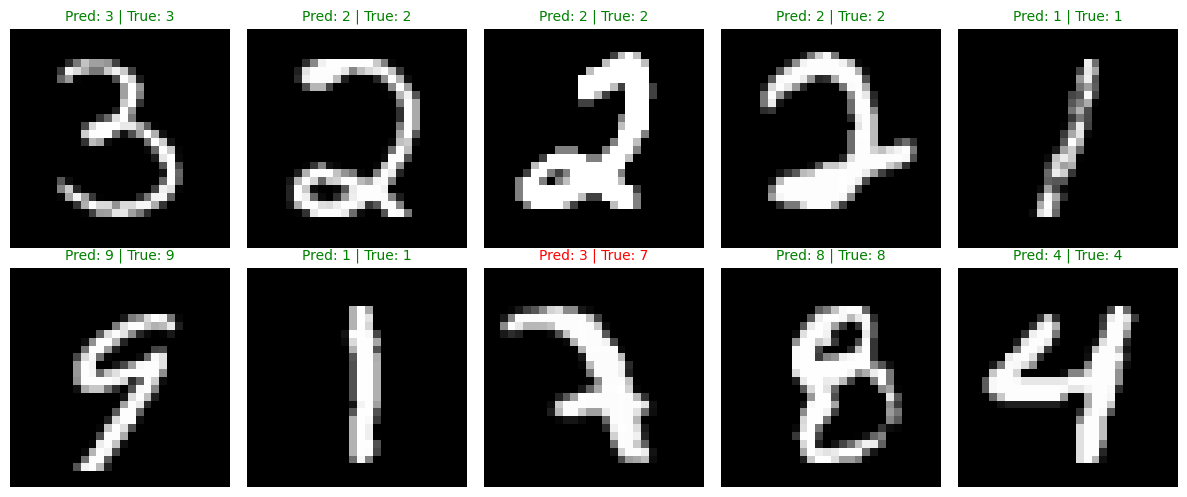

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_predictions(model, data_loader, device, num_images=10):
    model.eval()  # Set model to evaluation mode

    # Grab a single batch of images and labels
    images, labels = next(iter(data_loader))

    # Move images to the same device as model for inference
    images_dev = images.to(device)

    # Get predictions
    with torch.no_grad():
        outputs = model(images_dev)
        _, preds = outputs.max(1)

    # Move everything back to CPU and convert to numpy for plotting
    images = images.cpu().numpy()
    labels = labels.numpy()
    preds = preds.cpu().numpy()

    # Set up the matplotlib figure grid
    cols = 5
    rows = (num_images + cols - 1) // cols
    plt.figure(figsize=(12, 2.5 * rows))

    for i in range(num_images):
        plt.subplot(rows, cols, i + 1)

        # Undo the normalization math so the image looks normal to humans
        # MNIST mean=0.1307, std=0.3081 -> image = (pixel * std) + mean
        img = images[i].squeeze()  # Remove the channel dimension [1, 28, 28] -> [28, 28]
        img = (img * 0.3081) + 0.1307
        img = np.clip(img, 0, 1)    # Ensure values stay between 0 and 1

        plt.imshow(img, cmap='gray')

        # Color the title green if correct, red if wrong
        color = 'green' if preds[i] == labels[i] else 'red'
        plt.title(f"Pred: {preds[i]} | True: {labels[i]}", color=color, fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Run the function using your test_loader!
plot_predictions(model, val_loader, device, num_images=10)